### Part 0: Imports & Setup

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim

from scipy.io import arff
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Fixes randomness for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device detection
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"PyTorch version : {torch.__version__}")
print(f"Running on      : {device.upper()}")

PyTorch version : 2.11.0+cu130
Running on      : CPU


### Part 1: Data Loading

In [24]:
# ── Load ──────────────────────────────────────────────────────────────────────
wine         = load_wine()
X            = wine.data          # numpy array (150, 4)
y            = wine.target
FEATURE_NAMES = wine.feature_names # list of feature names
CLASS_NAMES  = wine.target_names  # ['class 0', 'class 1', 'class 2']

### Part 2: Exploratory Data Analysis (EDA)

In [ ]:
# ── Basic facts ───────────────────────────────────────────────────────────────
print(f"X shape : {X.shape}  →  {X.shape[0]} samples, {X.shape[1]} features")
print(f"Feature"s : {FEATURE_NAMES}")
print(f"Classes : {list(CLASS_NAMES)}")
print()

# ── Class balance ─────────────────────────────────────────────────────────────
# This dataset is perfectly balanced: 50 samples per class.
print("Class Distribution:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  Class {i} ({name}) : {np.sum(y == i)} samples")
print()

# ── Feature ranges ────────────────────────────────────────────────────────────
# Sepal length: 4-8 cm. Petal width: 0-2.5 cm.
# These different scales will hurt gradient descent → we must normalize.
print(f"{'Feature':<25} {'Min':>5}  {'Max':>5}")
print("-" * 38)
for i, name in enumerate(wine.feature_names):
    print(f"{name:<25} {X[:,i].min():>5.1f}  {X[:,i].max():>5.1f}")

0 : alcohol
1 : malic_acid
2 : ash
3 : alcalinity_of_ash
4 : magnesium
5 : total_phenols
6 : flavanoids
7 : nonflavanoid_phenols
8 : proanthocyanins
9 : color_intensity
10 : hue
11 : od280/od315_of_diluted_wines
12 : proline

Features sorted by discriminative power:
flavanoids                : 0.1945
color_intensity           : 0.1730
alcohol                   : 0.1416
proline                   : 0.1370
od280/od315_of_diluted_wines : 0.1118
hue                       : 0.0769
total_phenols             : 0.0351
malic_acid                : 0.0331
alcalinity_of_ash         : 0.0299
magnesium                 : 0.0259
proanthocyanins           : 0.0184
ash                       : 0.0155
nonflavanoid_phenols      : 0.0073


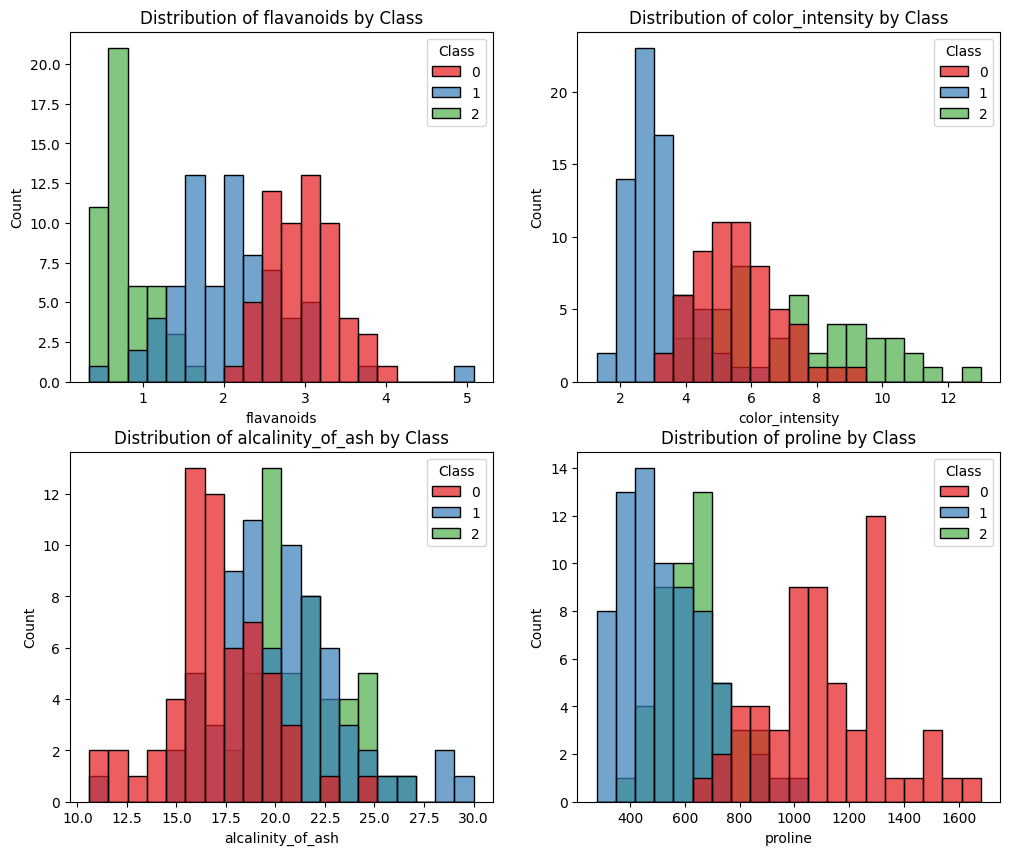

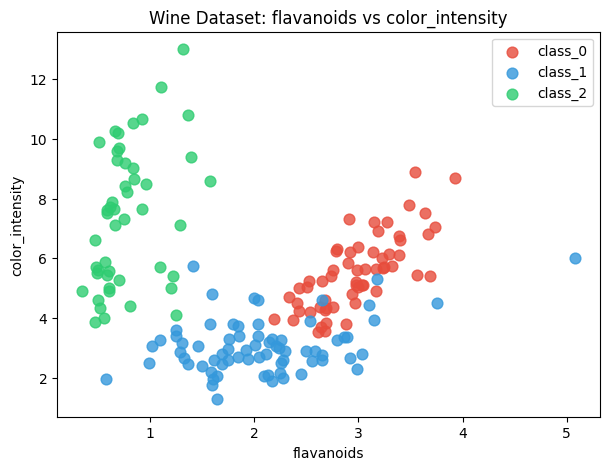

In [40]:
# List out the feature names
for i, name in enumerate(FEATURE_NAMES):
    print(f"{i} : {name}")
print()

# Returns a score for each feature (higher = more discriminative)
model = RandomForestClassifier(random_state=42)
model.fit(X, y)
feature_importance_pairs = list(zip(FEATURE_NAMES, model.feature_importances_))
sorted_features = sorted(feature_importance_pairs, key=lambda x: x[1], reverse=True)
print("Features sorted by discriminative power:")
for name, score in sorted_features:
    print(f"{name:25} : {score:.4f}")

# Most discriminative features: flavanoids, color_intensity, proline, od280/od315_of_diluted_wines
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
df_hist = pd.DataFrame({
    wine.feature_names[6]: X[:, 6],
    wine.feature_names[9]: X[:, 9],
    wine.feature_names[3]: X[:, 3],
    wine.feature_names[12]: X[:, 12],
    'Class': y
})
sns.histplot(data=df_hist, x=wine.feature_names[6], hue='Class', palette='Set1', ax=axes[0, 0], bins=20, alpha=0.7)
sns.histplot(data=df_hist, x=wine.feature_names[9], hue='Class', palette='Set1', ax=axes[0, 1], bins=20, alpha=0.7)
sns.histplot(data=df_hist, x=wine.feature_names[3], hue='Class', palette='Set1', ax=axes[1, 0], bins=20, alpha=0.7)
sns.histplot(data=df_hist, x=wine.feature_names[12], hue='Class', palette='Set1', ax=axes[1, 1], bins=20, alpha=0.7)
axes[0, 0].set_title(f"Distribution of {wine.feature_names[6]} by Class")
axes[0, 0].set_xlabel(wine.feature_names[6])
axes[0, 0].set_ylabel("Count")
axes[0, 1].set_title(f"Distribution of {wine.feature_names[9]} by Class")
axes[0, 1].set_xlabel(wine.feature_names[9])
axes[0, 1].set_ylabel("Count")
axes[1, 0].set_title(f"Distribution of {wine.feature_names[3]} by Class")
axes[1, 0].set_xlabel(wine.feature_names[3])
axes[1, 0].set_ylabel("Count")
axes[1, 1].set_title(f"Distribution of {wine.feature_names[12]} by Class")
axes[1, 1].set_xlabel(wine.feature_names[12])
axes[1, 1].set_ylabel("Count")
plt.show()
    
# ── Quick scatter: flavanoids vs color_intensity ────────────────────────
COLORS = ['#e74c3c', '#3498db', '#2ecc71']
fig, ax = plt.subplots(figsize=(7, 5))
    
for i, name in enumerate(CLASS_NAMES):
    mask = (y == i)
    ax.scatter(X[mask, 6], X[mask, 9], c=COLORS[i], label=name, s=60, alpha=0.8)
ax.set_xlabel(wine.feature_names[6])
ax.set_ylabel(wine.feature_names[9])
ax.set_title(f"Wine Dataset: {wine.feature_names[6]} vs {wine.feature_names[9]}")
ax.legend()
plt.show()
    

### Part 3: Prepare Data for Training

In [41]:
# Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"Train : {X_train.shape}  ({len(X_train)} samples)")
print(f"Test  : {X_test.shape}   ({len(X_test)} samples)")
print()

Train : (142, 13)  (142 samples)
Test  : (36, 13)   (36 samples)



In [42]:
# Scale data for training
scaler  = StandardScaler()

X_train = scaler.fit_transform(X_train)  # Learns μ and σ from training data
X_test  = scaler.transform(X_test)       # Applies training μ/σ to test — no leakage!

print(f"After scaling — Train mean : {X_train.mean(axis=0).round(2)}  (should be ≈ 0)")
print(f"After scaling — Train std  : {X_train.std(axis=0).round(2)}   (should be ≈ 1)")
print()

After scaling — Train mean : [ 0. -0.  0.  0.  0. -0.  0. -0. -0.  0. -0.  0. -0.]  (should be ≈ 0)
After scaling — Train std  : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]   (should be ≈ 1)



In [43]:
# ── Convert to tensors ────────────────────────────────────────────────────
X_train_t = torch.tensor(X_train, dtype=torch.float32)  # float32 for features
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)     # int64 for class labels!
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

print(f"X_train_t : {X_train_t.shape}  dtype={X_train_t.dtype}")
print(f"y_train_t : {y_train_t.shape}   dtype={y_train_t.dtype}  ← must be long for CrossEntropyLoss")

X_train_t : torch.Size([142, 13])  dtype=torch.float32
y_train_t : torch.Size([142])   dtype=torch.int64  ← must be long for CrossEntropyLoss


### Part 4: Build The Neural Network

In [47]:
class WineNet(nn.Module):
    """
    A simple 2-layer neural network for 3-class Wine classification.

    Architecture:  Linear(4→16) → ReLU → Linear(16→3)
    Output: raw logits (3 scores, one per class). No Softmax here.
    """

    def __init__(self):
        super().__init__()  # ALWAYS first — initialises nn.Module machinery

        self.layer1 = nn.Linear(13, 16)
        # nn.Linear(in_features, out_features)
        # Creates a weight matrix (16×13) and bias (16,) automatically
        # and registers them as learnable Parameters.

        self.relu = nn.ReLU()
        # Activation function: f(x) = max(0, x)
        # WHY: Without activations, stacking Linear layers is
        # mathematically equivalent to ONE Linear layer — the network
        # can only draw straight lines. ReLU adds non-linearity,
        # enabling the network to learn curved decision boundaries.

        self.layer2 = nn.Linear(16, 3)
        # Maps 16 hidden neurons → 3 output scores (one per class)
        # No Softmax! CrossEntropyLoss handles that internally.

    def forward(self, x):
        """
        How data flows through the network.
        Called automatically when you do: model(x)

        x in  : (batch_size, 13)
        x out : (batch_size, 3)  — 3 raw class scores
        """
        x = self.layer1(x)   # (batch, 4)  → (batch, 16)
        x = self.relu(x)     # (batch, 16) → (batch, 16)  same shape
        x = self.layer2(x)   # (batch, 16) → (batch, 3)
        return x              # Raw logits — not probabilities


# ── Create model and move to device ──────────────────────────────────────────
model = WineNet().to(device)
print(model)
print()

# Count total parameters — understand what your model actually contains
total = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {total}")
# layer1 : 13×16 weights + 16 biases = 224
# layer2 : 16×3 weights +  3 biases = 51
# Total  : 275  — a tiny model, perfect for Wine

# ── Forward pass sanity check ────────────────────────────────────────────────
# Before training, verify the shapes work end-to-end.
with torch.no_grad():
    dummy_out = model(torch.randn(5, 13).to(device))
print(f"\nDummy forward pass: input (5, 13) → output {tuple(dummy_out.shape)}  ✅")

WineNet(
  (layer1): Linear(in_features=13, out_features=16, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=16, out_features=3, bias=True)
)

Total trainable parameters: 275

Dummy forward pass: input (5, 13) → output (5, 3)  ✅


### Part 5: Train the Model

In [48]:
import math

# ── Loss function ─────────────────────────────────────────────────────────────
# CrossEntropyLoss is the standard choice for multi-class classification.
# It expects: raw logits (batch, num_classes)  +  integer labels (batch,)
# Internally it applies Softmax → that is why forward() must NOT add Softmax.
loss_fn = nn.CrossEntropyLoss()

# ── Optimizer ─────────────────────────────────────────────────────────────────
# Adam: adapts the learning rate per parameter. The safest first choice.
# lr=0.01: step size. Too large → loss oscillates. Too small → barely moves.
# model.parameters() gives Adam references to all weights and biases.
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ── Initial loss sanity check ─────────────────────────────────────────────────
# Before any training, a randomly initialised model on 3 classes
# should give loss ≈ log(3) ≈ 1.099.
# If it's wildly different, your data pipeline already has a bug.
model.eval()
with torch.no_grad():
    init_loss = loss_fn(model(X_train_t.to(device)), y_train_t.to(device))
print(f"Initial loss: {init_loss.item():.4f}   (expected ≈ {math.log(3):.4f})")
print()

Initial loss: 1.1169   (expected ≈ 1.0986)



In [49]:
# ── The 5-Step Training Loop ──────────────────────────────────────────────────
EPOCHS = 100
train_losses = []   # Collect for plotting — use .item() not the tensor itself!

for epoch in range(1, EPOCHS + 1):

    model.train()   # Switch to training mode.
    # For this simple model it has no effect, but it's the correct habit:
    # models with Dropout or BatchNorm behave differently in train vs eval.

    # Step 1: Forward pass ────────────────────────────────────────────────────
    # Run all 120 training samples through the network.
    # (For large datasets you'd loop over mini-batches — same 5 steps inside)
    logits = model(X_train_t.to(device))              # shape: (120, 3)

    # Step 2: Compute loss ────────────────────────────────────────────────────
    loss = loss_fn(logits, y_train_t.to(device))      # scalar tensor

    # Step 3: Zero old gradients ──────────────────────────────────────────────
    # PyTorch ACCUMULATES gradients. Without this, gradients from the
    # previous epoch are still in .grad and get added to the new ones.
    # Result: effective gradient grows every epoch → training explodes.
    # This is the #1 most common PyTorch bug. Never skip this line.
    optimizer.zero_grad()

    # Step 4: Backpropagation ─────────────────────────────────────────────────
    # Computes ∂loss/∂(every weight) using the chain rule — automatically.
    # Each parameter's .grad attribute is filled in after this call.
    loss.backward()

    # Step 5: Update weights ──────────────────────────────────────────────────
    # Adam reads each parameter's .grad and nudges the weight
    # in the direction that reduces the loss.
    optimizer.step()

    # Track — use .item() to get a plain float, NOT the tensor
    # Storing the tensor keeps the computation graph alive → memory leak
    train_losses.append(loss.item())

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}/{EPOCHS}  |  Loss: {loss.item():.4f}")

print("\n✅ Training complete!")

Epoch  20/100  |  Loss: 0.1714
Epoch  40/100  |  Loss: 0.0270
Epoch  60/100  |  Loss: 0.0104
Epoch  80/100  |  Loss: 0.0063
Epoch 100/100  |  Loss: 0.0044

✅ Training complete!


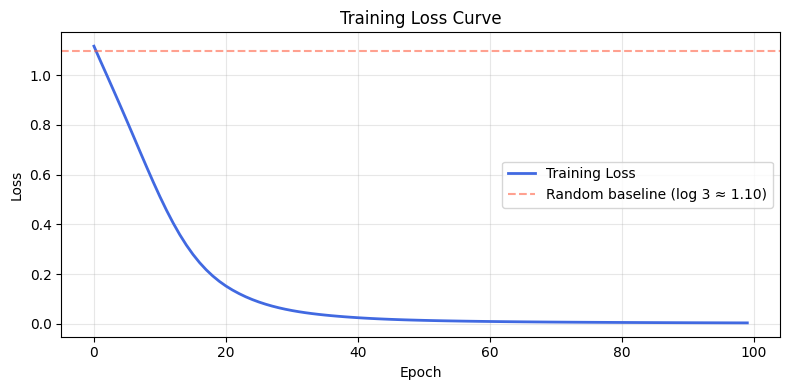

In [50]:
# ── Plot the learning curve ───────────────────────────────────────────────────
# This is your model's vital-signs chart. Learn to read it:
#
#   ✅  Loss steadily going down       → model is learning correctly
#   ❌  Loss barely moves              → learning rate too small, or data not scaled
#   ❌  Loss oscillates up and down    → learning rate too large
#   ❌  Loss shoots up toward infinity → learning rate way too large (diverging)

plt.figure(figsize=(8, 4))
plt.plot(train_losses, color='royalblue', lw=2, label='Training Loss')
plt.axhline(y=math.log(3), color='tomato', linestyle='--', alpha=0.6,
            label=f'Random baseline (log 3 ≈ {math.log(3):.2f})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Part 6: Model Evaluation

In [51]:
# ── Switch to evaluation mode ─────────────────────────────────────────────────
model.eval()

with torch.no_grad():   # No gradients needed — saves memory and time
    test_logits = model(X_test_t.to(device))        # (30, 3) raw scores
    predictions = torch.argmax(test_logits, dim=1)  # pick class with highest score

predictions_np = predictions.cpu().numpy()

correct  = (predictions_np == y_test).sum()
accuracy = correct / len(y_test)

print(f"Test Accuracy: {correct}/{len(y_test)} = {accuracy:.1%}")
print()

# ── Per-class accuracy ────────────────────────────────────────────────────────
# Overall accuracy can hide per-class failures. Always break it down.
# Example: 93% overall might mean 100% on Setosa but only 80% on Virginica.
print("Per-class accuracy:")
for i, name in enumerate(CLASS_NAMES):
    mask    = (y_test == i)
    cls_acc = (predictions_np[mask] == i).mean()
    print(f"  {name:<12} : {cls_acc:.0%}  ({mask.sum()} test samples)")

Test Accuracy: 35/36 = 97.2%

Per-class accuracy:
  class_0      : 100%  (12 test samples)
  class_1      : 100%  (14 test samples)
  class_2      : 90%  (10 test samples)


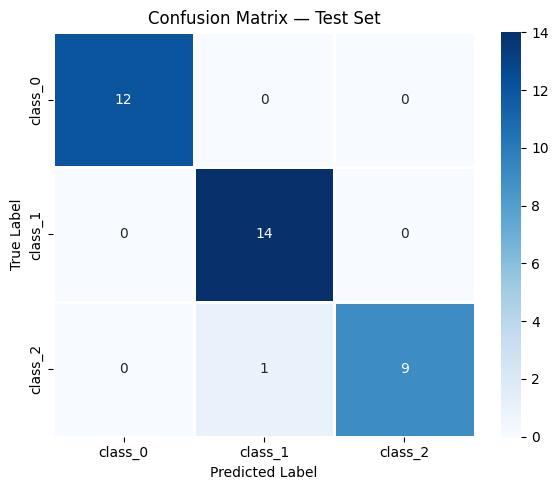

In [52]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
# Shows WHICH classes the model confuses with each other.
#
# How to read it:
#   Each ROW = the true class
#   Each COLUMN = what the model predicted
#   Diagonal = correct predictions (want these to be large)
#   Off-diagonal = errors (want these to be 0)

cm = confusion_matrix(y_test, predictions_np)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=1, linecolor='white')
plt.title('Confusion Matrix — Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()